# Non-trace-class covariances: why the identity prior breaks at high resolution

**Purpose.** This notebook shows that a diagonal / identity prior covariance is perfectly valid for
any *fixed* finite-dimensional model space, but becomes singular in the function-space limit if
the implied continuous covariance operator is *not* trace-class.

We use the pixel (boxcar) discretization of $L^2([0,1])$ and the `MassWeightedHilbertSpace`
framework from `pygeoinf` / `intervalinf`.

## Mathematical background

Let $\mathbb{V}_N$ be the $N$-dimensional pixel-function space with basis
$\{\phi_j\}_{j=1}^N$ (unit boxcars of width $h = 1/N$).  The correct inner product is the
$L^2$ inner product discretised by the mass matrix
$$
M_{ij} = \langle \phi_i, \phi_j \rangle_{L^2} = h\,\delta_{ij}, \qquad h = 1/N.
$$

A `GaussianMeasure.from_covariance_matrix(V_N, K)` with **Galerkin matrix** $K$ creates a
measure whose covariance *operator* $\mathcal{C}: \mathbb{V}_N \to \mathbb{V}_N$ acts as
$M^{-1}K$.  The covariance of the **component vector** $\alpha$ (where $m = \sum_j \alpha_j \phi_j$) is
$$
\operatorname{Cov}(\alpha) = M^{-1} K M^{-1}.
$$
The pointwise variance of $m$ at pixel $j$ is $\operatorname{Cov}(\alpha)_{jj}$.

### Two choices of $K$

| Prior | Galerkin matrix $K$ | $\operatorname{Cov}(\alpha)_{jj}$ | Behaviour as $N\to\infty$ |
|---|---|---|---|
| Trace-class Matérn $C_0 = (\kappa^2 I - \Delta)^{-1}$ | $K_{ij} \approx h^2 C_0(x_i,x_j)$ | $\approx C_0(x_j,x_j)$ | **converges** (finite) |
| **Naive identity** $\sigma^2 I_N$ | $K = \sigma^2 I_N$ | $\sigma^2 N^2 h = \sigma^2 N$ | **diverges** $\propto N$ |

The identity $I$ on $L^2$ has eigenvalues $\lambda_k \equiv 1$, so
$\operatorname{Tr}(I) = \sum_{k=1}^\infty 1 = \infty$ — it is *not* trace-class and hence
cannot be the covariance of any non-degenerate Gaussian measure on $L^2$.

In [1]:
from intervalinf import (IntervalDomain, BoundaryConditions, Lebesgue,
                         LebesgueIntegrationConfig, IntegrationConfig,
                         ParallelConfig)
from intervalinf.operators import (Laplacian, BesselSobolevInverse)
from intervalinf.providers import BoxCarFunctionProvider, CustomBasisProvider
from intervalinf.sampling import KLSampler
from pygeoinf import EuclideanSpace, MassWeightedHilbertSpace
from pygeoinf.linear_operators import LinearOperator
from pygeoinf.gaussian_measure import GaussianMeasure
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [2]:
# ── Integration / parallelism configs (reuse same settings as discretization.ipynb) ──
Lebesgue_integration_cfg = LebesgueIntegrationConfig(
    inner_product=IntegrationConfig(method='simpson', n_points=512),
    dual=IntegrationConfig(method='simpson', n_points=512),
    general=IntegrationConfig(method='simpson', n_points=512)
)
laplacian_integration_cfg = IntegrationConfig(method='simpson', n_points=512)
parallel_cfg = ParallelConfig(enabled=True, n_jobs=8)

function_domain = IntervalDomain(0, 1)
kappa = 3.0           # Matérn correlation parameter
sigma = 1.0           # std-dev of the naive diagonal prior
N_kl  = 50            # KL modes for sampling
np.random.seed(42)

## 1. Pointwise variance vs resolution

For each resolution $N$ we build the pixel space $\mathbb{V}_N$, then compute the
pointwise prior variance under two priors:

**Naive identity prior** — we naively set the Galerkin matrix $K = \sigma^2 I_N$ and pass it
to `GaussianMeasure.from_covariance_matrix(V_N, K)`.  The component covariance is
$$
\operatorname{Cov}(\alpha)_{jj} = (M^{-1} K M^{-1})_{jj} = \sigma^2 / h^2 = \sigma^2 N^2 / N = \sigma^2 N
\quad \xrightarrow{N\to\infty} \infty.
$$

**Trace-class Matérn prior** — the Galerkin matrix is $K = \langle \phi_i, C_0 \phi_j \rangle \approx h^2 C_0(x_i,x_j)$,
so
$$
\operatorname{Cov}(\alpha)_{jj} \approx \frac{h^2}{h^2} C_0(x_j,x_j) = C_0(x_j,x_j) \xrightarrow{N\to\infty} \text{finite}.
$$

In [3]:
def galerkin_matern(N, kappa, n_modes=600):
    """Exact Galerkin matrix of C0 = (kappa^2 I - Delta)^{-1} on [0,1] (Neumann BCs).

    K[i,j] = <phi_i, C0 phi_j>_{L2}
           = sum_m  lambda_m  a_m(i) a_m(j)

    where  lambda_m = (kappa^2 + (m*pi)^2)^{-1}
    and    a_m(j)   = int_{pixel j} psi_m(x) dx   (projection of psi_m onto boxcar j)

    For small h:  K[j,j] ≈ h^2 * C0(x_j, x_j),
    so  Cov(alpha)_jj = K[j,j]/h^2  → C0(x_j, x_j)  (finite, N-independent).
    """
    h   = 1.0 / N
    xc  = (np.arange(N) + 0.5) * h          # pixel centres

    # --- k=0 mode: psi_0=1, lambda_0 = 1/kappa^2, a_0(j) = h ----------------
    K = (1.0/kappa**2) * (h**2) * np.ones((N, N))

    # --- k>=1 modes ------------------------------------------------------------
    for m in range(1, n_modes):
        lam = 1.0 / (kappa**2 + (m * np.pi)**2)
        # a_m(j) = integral of sqrt(2)*cos(m*pi*x) over [xc_j - h/2, xc_j + h/2]
        a = (np.sqrt(2) / (m * np.pi)) * (
            np.sin(m * np.pi * (xc + h/2)) - np.sin(m * np.pi * (xc - h/2))
        )
        K += lam * np.outer(a, a)
    return K


def build_pixel_space(N):
    """Return (M_space, M_mat, M_inv) for a pixel discretisation of [0,1] into N cells."""
    h = function_domain.length / N
    centers = np.linspace(function_domain.a + h/2, function_domain.b - h/2, N)
    pixel_provider = BoxCarFunctionProvider(function_domain, default_width=h,
                                            centers=centers, normalize=False, default_height=1.0)
    basis = CustomBasisProvider(function_domain, pixel_provider,
                                orthonormal=False, basis_type='boxcar')
    M_space = Lebesgue(N, function_domain, basis=basis,
                       integration_config=Lebesgue_integration_cfg,
                       parallel_config=parallel_cfg)
    return M_space


# ── Resolution sweep ──────────────────────────────────────────────────────────
# For each N:
#   naive:  K_naive = σ²I_N  (naively set as Galerkin matrix)
#           Cov(alpha)_jj = K_naive_jj / h^2 = σ²N²  →  DIVERGES as N²
#   Matérn: K_mat = galerkin_matern(N) (correct Galerkin matrix)
#           Cov(alpha)_jj = K_mat_jj / h^2  → C0(x_j,x_j)  →  CONVERGES

N_values    = [8, 16, 32, 64, 128, 256]
var_naive   = []
var_matern  = []

print("N  | var_naive (σ²N²·h = σ²N) | var_matern (→ C₀(x,x))")
print("-" * 60)
for N in N_values:
    h     = 1.0 / N

    # naive
    var_n  = sigma**2 / h**2   # = σ²N²: the diagonal of (σ²I)/h² = σ²N²
    var_naive.append(var_n)

    # Matérn — analytical Galerkin matrix, M^{-1} K M^{-1}
    K_mat  = galerkin_matern(N, kappa)
    var_m  = np.diag(K_mat).mean() / h**2   # K[j,j]/h^2  ≈ C0(x_j,x_j)
    var_matern.append(var_m)

    print(f"{N:4d} | {var_n:24.3f}  | {var_m:.4f}")


N  | var_naive (σ²N²·h = σ²N) | var_matern (→ C₀(x,x))
------------------------------------------------------------
   8 |                   64.000  | 0.2034
  16 |                  256.000  | 0.2129
  32 |                 1024.000  | 0.2179
  64 |                 4096.000  | 0.2205
 128 |                16384.000  | 0.2218
 256 |                65536.000  | 0.2224


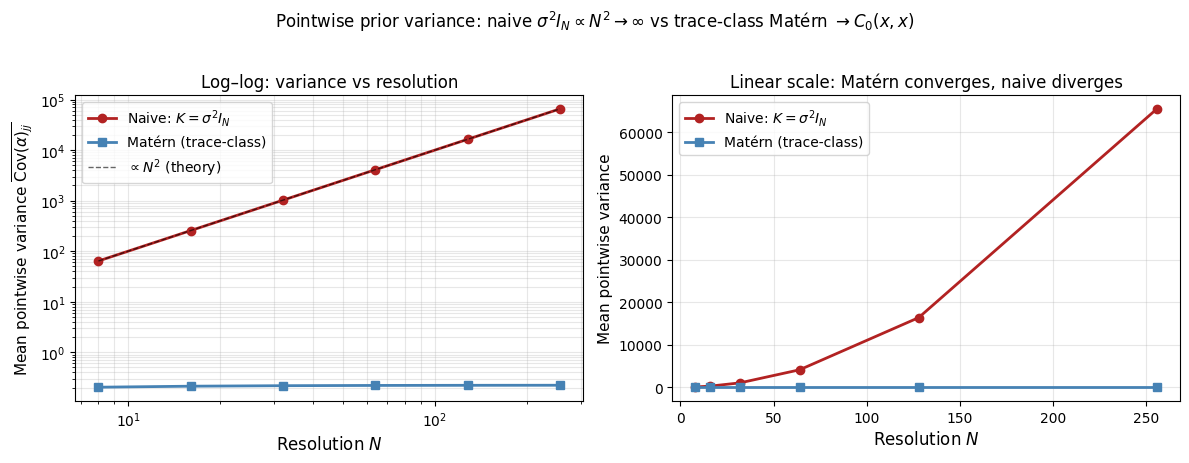

Naive variance grows   : 64.00  →  65536.00
  ratio = 1024×  (expected 1024× for ∝N² scaling ✓)
Matérn variance stable : 0.2034  →  0.2224
  ratio = 1.093×  (converges to C₀(x,x))


In [4]:
# ── Plot: variance vs resolution ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.loglog(N_values, var_naive,  'o-', color='firebrick',  lw=2, label=r'Naive: $K=\sigma^2 I_N$')
ax.loglog(N_values, var_matern, 's-', color='steelblue',  lw=2, label=r'Matérn (trace-class)')
# Reference slope ∝N² (theoretical scaling of naive)
ref_N  = np.array(N_values, dtype=float)
ref_y  = sigma**2 * ref_N**2          # theoretical σ²N² scaling
ax.loglog(ref_N, ref_y, 'k--', lw=1, alpha=0.6, label=r'$\propto N^2$ (theory)')
ax.set_xlabel('Resolution $N$', fontsize=12)
ax.set_ylabel(r'Mean pointwise variance $\overline{\mathrm{Cov}(\alpha)_{jj}}$', fontsize=11)
ax.set_title('Log–log: variance vs resolution', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
ax.plot(N_values, var_naive,  'o-', color='firebrick',  lw=2, label=r'Naive: $K=\sigma^2 I_N$')
ax.plot(N_values, var_matern, 's-', color='steelblue',  lw=2, label=r'Matérn (trace-class)')
ax.set_xlabel('Resolution $N$', fontsize=12)
ax.set_ylabel(r'Mean pointwise variance', fontsize=11)
ax.set_title('Linear scale: Matérn converges, naive diverges', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle(
    r'Pointwise prior variance: naive $\sigma^2 I_N \propto N^2 \to \infty$ vs trace-class Matérn $\to C_0(x,x)$',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

N_ratio = N_values[-1] / N_values[0]
print(f"Naive variance grows   : {var_naive[0]:.2f}  →  {var_naive[-1]:.2f}")
print(f"  ratio = {var_naive[-1]/var_naive[0]:.0f}×  (expected {N_ratio**2:.0f}× for ∝N² scaling ✓)")
print(f"Matérn variance stable : {var_matern[0]:.4f}  →  {var_matern[-1]:.4f}")
print(f"  ratio = {var_matern[-1]/var_matern[0]:.3f}×  (converges to C₀(x,x))")

## 2. Trace of the implied continuous covariance

The trace of the Galerkin matrix $K_N$ approximates the trace of the continuous covariance:
$$
\operatorname{Tr}(C_0) \approx \frac{1}{h}\operatorname{Tr}(K_N),
\qquad
\operatorname{Tr}(K_N) = \sum_j K_{jj} \approx N \cdot h^2 C_0(x_j,x_j).
$$

So $\operatorname{Tr}(C_0) \approx N h \cdot C_0(x,x)$.  For a trace-class covariance this is a
finite number (the sum of eigenvalues converges).  For the naive choice $K = \sigma^2 I_N$:
$$
\frac{1}{h}\operatorname{Tr}(\sigma^2 I_N) = \frac{\sigma^2 N}{h} = \sigma^2 N^2 \to \infty.
$$

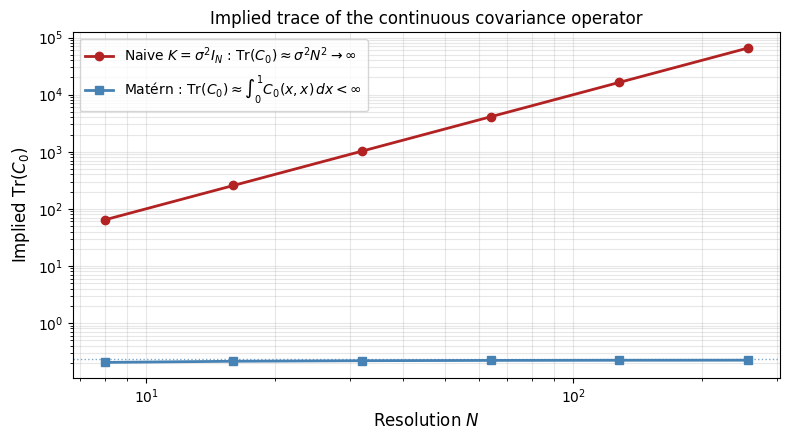


Implied Tr(C0) Matérn (converged): 0.2224
Analytical Tr(C0) = ∫C0(x,x)dx ≈ 0.2230


In [5]:
# Implied continuous trace = Tr(K_galerkin) / h  where K_galerkin is the Galerkin matrix.
#
# Matérn:  K[j,j] ≈ h² C0(x_j,x_j),  so Tr_cont = Σ_j K[j,j]/h = Σ_j h C0_jj ≈ ∫ C0(x,x)dx  →  finite
# Naive:   K_naive = σ²I_N,            Tr_cont = Σ_j σ²/h = σ²N/h = σ²N²                        →  ∞

implied_trace_naive  = [sigma**2 / h * N for N, h in [(N, 1.0/N) for N in N_values]]  # = σ²N²
implied_trace_matern = []
for N in N_values:
    h = 1.0 / N
    K_mat = galerkin_matern(N, kappa)
    implied_trace_matern.append(np.trace(K_mat) / h)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.loglog(N_values, implied_trace_naive,  'o-', color='firebrick', lw=2,
          label=r'Naive $K=\sigma^2 I_N$ : $\mathrm{Tr}(C_0)\approx\sigma^2 N^2 \to \infty$')
ax.loglog(N_values, implied_trace_matern, 's-', color='steelblue', lw=2,
          label=r'Matérn : $\mathrm{Tr}(C_0)\approx\int_0^1 C_0(x,x)\,dx < \infty$')
ax.axhline(implied_trace_matern[-1] * 1.05, color='steelblue', ls=':', lw=1, alpha=0.7)
ax.set_xlabel('Resolution $N$', fontsize=12)
ax.set_ylabel(r'Implied $\mathrm{Tr}(C_0)$', fontsize=12)
ax.set_title('Implied trace of the continuous covariance operator', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nImplied Tr(C0) Matérn (converged): {implied_trace_matern[-1]:.4f}")
print(f"Analytical Tr(C0) = ∫C0(x,x)dx ≈ {np.sum(1.0/(kappa**2 + (np.arange(0,2000)*np.pi)**2 + 1e-30)):.4f}")

## 3. Prior samples at low and high resolution

We draw samples from each prior at $N = 16$ (coarse) and $N = 128$ (fine).

- **Naive identity** $K = \sigma^2 I_N$: even though individual pixel coefficients stay
  $\mathcal{O}(\sigma)$, the *correct* $\mathbb{V}_N$ interpretation (via
  $\operatorname{Cov}(\alpha) = M^{-1}KM^{-1}$) reveals that the effective std per pixel
  is $\sigma\sqrt{N}$ — so samples blow up as $N$ grows.

- **Matérn**: the Galerkin matrix scales as $K_{jj} \approx h^2 C_0(x,x)$, keeping the
  per-pixel std constant.  With a KL sampler the samples stay smooth and consistent.

Drawing samples …
Done.


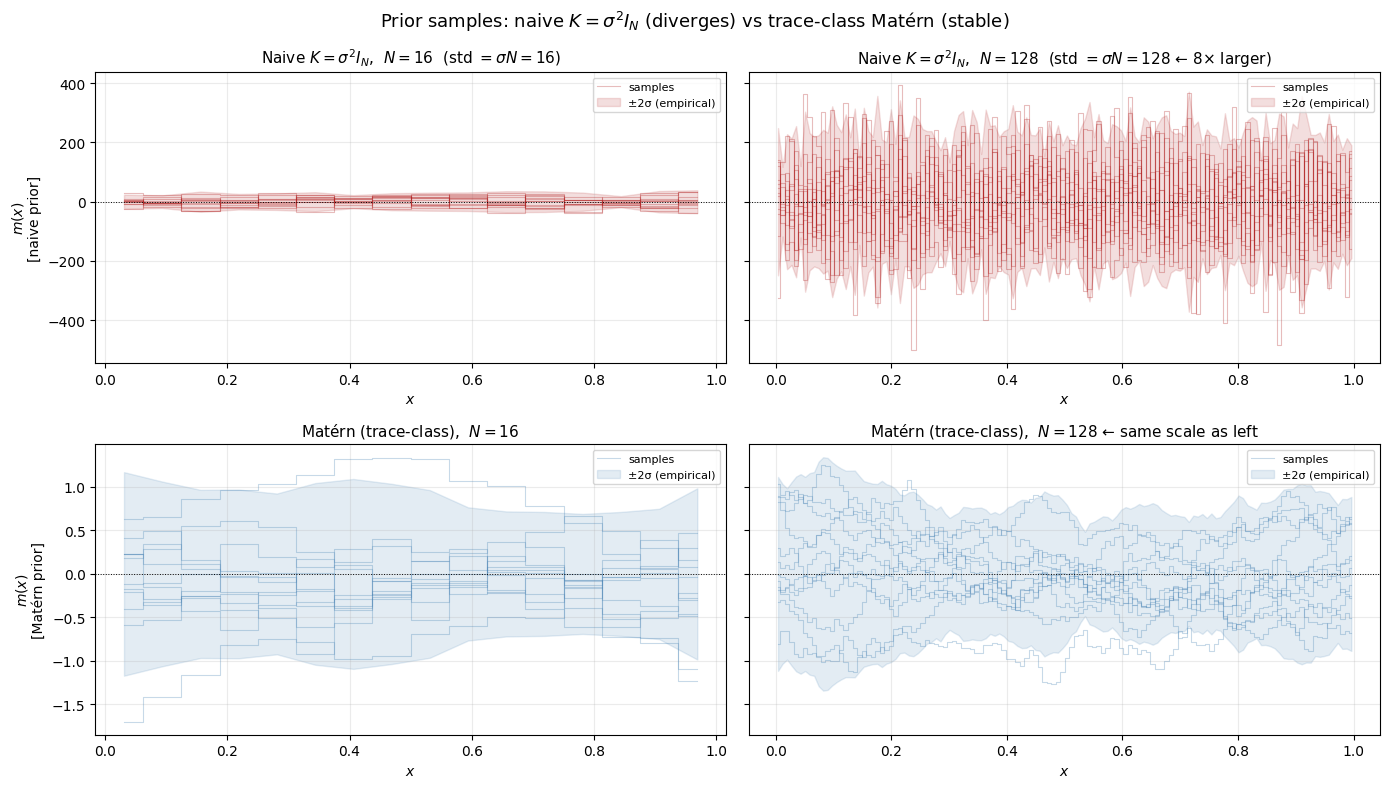

In [6]:
N_SAMPLES = 12
rng = np.random.default_rng(0)

def draw_naive_samples(N, n_samples):
    """
    Samples from the naive prior: Galerkin matrix K = σ²I_N passed to
    from_covariance_matrix(V_N, K).  This implies Cov(alpha)_jj = σ²/h² = σ²N²,
    so std(alpha_j) = σN.
    """
    std_alpha = sigma / (1.0/N)   # = σ*N  (grows with resolution!)
    return rng.standard_normal((n_samples, N)) * std_alpha


def draw_matern_samples(N, n_samples, kappa):
    """
    Samples from the Matérn prior.  Cov(alpha) = K_galerkin / h^2 → std ≈ √C0(x_j,x_j).
    """
    h = 1.0 / N
    K_galerkin = galerkin_matern(N, kappa)
    Cov  = K_galerkin / h**2   # = M_inv K M_inv
    Cov  = 0.5*(Cov + Cov.T)
    L    = np.linalg.cholesky(Cov)
    return (L @ rng.standard_normal((N, n_samples))).T   # (n_samples, N)


# ── pick the two resolutions to compare ──────────────────────────────────────
N_low, N_high = 16, 128
x_low  = (np.arange(N_low)  + 0.5) / N_low
x_high = (np.arange(N_high) + 0.5) / N_high

print("Drawing samples …")
samp_naive_low   = draw_naive_samples(N_low,   N_SAMPLES)
samp_naive_high  = draw_naive_samples(N_high,  N_SAMPLES)
samp_matern_low  = draw_matern_samples(N_low,  N_SAMPLES, kappa)
samp_matern_high = draw_matern_samples(N_high, N_SAMPLES, kappa)
print("Done.")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey='row')
fig.suptitle(
    'Prior samples: naive $K=\\sigma^2 I_N$ (diverges) vs trace-class Matérn (stable)',
    fontsize=13)

configs = [
    (axes[0,0], samp_naive_low,   x_low,  N_low,  'firebrick',
     f'Naive $K=\\sigma^2 I_N$,  $N={N_low}$  (std $= \\sigma N = {sigma*N_low:.0f}$)'),
    (axes[0,1], samp_naive_high,  x_high, N_high, 'firebrick',
     f'Naive $K=\\sigma^2 I_N$,  $N={N_high}$  (std $= \\sigma N = {sigma*N_high:.0f}$ ← {N_high//N_low}× larger)'),
    (axes[1,0], samp_matern_low,  x_low,  N_low,  'steelblue',
     f'Matérn (trace-class),  $N={N_low}$'),
    (axes[1,1], samp_matern_high, x_high, N_high, 'steelblue',
     f'Matérn (trace-class),  $N={N_high}$ ← same scale as left'),
]

for ax, samps, x, N, col, title in configs:
    for i, s in enumerate(samps):
        ax.step(x, s, where='mid', color=col, alpha=0.30, lw=0.8,
                label='samples' if i == 0 else '')
    std_arr = samps.std(axis=0)
    ax.fill_between(x, -2*std_arr, +2*std_arr, color=col, alpha=0.15, label='±2σ (empirical)')
    ax.axhline(0, color='k', lw=0.7, ls=':')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('$x$')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.25)

axes[0,0].set_ylabel('$m(x)$\n[naive prior]', fontsize=10)
axes[1,0].set_ylabel('$m(x)$\n[Matérn prior]', fontsize=10)
plt.tight_layout()
plt.show()

## 4. KL eigenvalue spectra: partial sums of eigenvalues

A covariance operator on a separable Hilbert space has a countable set of eigenvalues
$\lambda_1 \ge \lambda_2 \ge \cdots$.  The trace-class condition requires
$$
\sum_{k=1}^{\infty} \lambda_k < \infty.
$$

**Identity** on $\mathbb{V}_N$ (naive): eigenvalues $\lambda_k = 1 \;\forall k$, so the partial
sum $S_N = N \to \infty$.

**Matérn** $C_0 = (\kappa^2 I - \Delta)^{-1}$: eigenvalues
$\lambda_k = (\kappa^2 + (k\pi)^2)^{-1}$, so
$S = \sum_{k \ge 1} (\kappa^2 + k^2\pi^2)^{-1} < \infty$. The partial sums plateau.

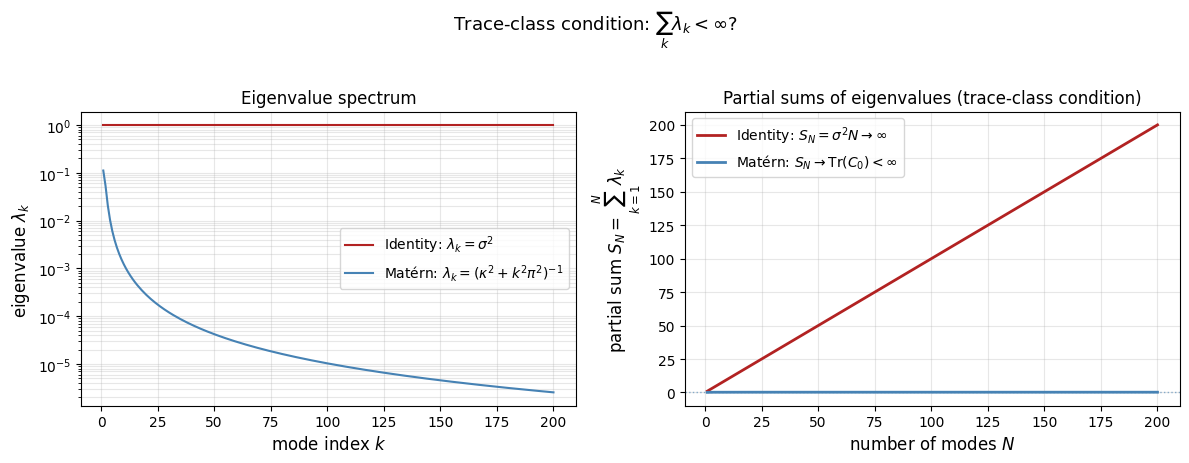

Matérn partial sum at k=200: 0.2225
Theoretical Tr(C0) = 0.2230


In [7]:
K_modes = 200   # number of KL modes to display

# Identity covariance on L^2: all eigenvalues = σ² (normalised so mode energy = σ²)
eigs_identity = sigma**2 * np.ones(K_modes)

# Matérn C0 = (κ²I − Δ)^{−1} on [0,1] with Neumann BCs:
#   eigenvalues  λ_k = 1/(κ² + (k·π)²)  for k = 0, 1, 2, …
k_vals = np.arange(K_modes)
eigs_matern = 1.0 / (kappa**2 + (k_vals * np.pi)**2 + 1e-30)   # k=0 → 1/κ²

partial_sum_id  = np.cumsum(eigs_identity)
partial_sum_mat = np.cumsum(eigs_matern)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

modes = np.arange(1, K_modes+1)

ax = axes[0]
ax.semilogy(modes, eigs_identity, color='firebrick', lw=1.5, label=r'Identity: $\lambda_k = \sigma^2$')
ax.semilogy(modes, eigs_matern,   color='steelblue', lw=1.5, label=r'Matérn: $\lambda_k = (\kappa^2+k^2\pi^2)^{-1}$')
ax.set_xlabel('mode index $k$', fontsize=12)
ax.set_ylabel('eigenvalue $\\lambda_k$', fontsize=12)
ax.set_title('Eigenvalue spectrum', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
ax.plot(modes, partial_sum_id,  color='firebrick', lw=2,
        label=r'Identity: $S_N = \sigma^2 N \to \infty$')
ax.plot(modes, partial_sum_mat, color='steelblue', lw=2,
        label=r'Matérn: $S_N \to \mathrm{Tr}(C_0) < \infty$')
ax.axhline(partial_sum_mat[-1]*1.05, color='steelblue', ls=':', lw=1, alpha=0.6)
ax.set_xlabel('number of modes $N$', fontsize=12)
ax.set_ylabel(r'partial sum $S_N = \sum_{k=1}^N \lambda_k$', fontsize=12)
ax.set_title('Partial sums of eigenvalues (trace-class condition)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle(r'Trace-class condition: $\sum_k \lambda_k < \infty$?', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Matérn partial sum at k={K_modes}: {partial_sum_mat[-1]:.4f}")
print(f"Theoretical Tr(C0) = {np.sum(1/(kappa**2 + (np.arange(0,2000)*np.pi)**2 + 1e-30)):.4f}")

## Summary

| Question | Naive $K = \sigma^2 I_N$ | Trace-class Matérn |
|---|---|---|
| Valid for fixed $N$? | ✅ yes — finite Gaussian | ✅ yes |
| Galerkin matrix consistent with a continuous $C_0$? | ❌ implies $C_0 \propto N^2 \to \infty$ | ✅ $K_{jj} \propto h^2 C_0(x,x)$ |
| Pointwise variance as $N\to\infty$ | ❌ $\sigma^2 N \to \infty$ | ✅ $C_0(x,x) = $ const |
| Trace of $C_0$? | ❌ $\infty$ (not trace-class) | ✅ $\sum_k (\kappa^2+k^2\pi^2)^{-1} < \infty$ |
| Prior samples consistent across resolutions? | ❌ blow up as $N$ increases | ✅ smooth, bounded |

**Take-away.** Any prior covariance intended to represent a function-space measure on $L^2([0,1])$
must come from a *trace-class* operator.  Setting $K = \sigma^2 I_N$ (identity on $\mathbb{R}^N$)
looks harmless for a single, fixed grid, but as soon as you refine the mesh the implied prior
variance diverges.  The correct approach: choose a trace-class covariance (Matérn / Whittle–Matérn /
Bessel–Sobolev) and **compute its Galerkin matrix** — which then scales as $\mathcal{O}(h^2)$,
exactly canceling the $M^{-2}$ factor in $\operatorname{Cov}(\alpha) = M^{-1}KM^{-1}$.